In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
# import plotly.express as px
import os
import warnings

# Local server SQL database
import sqlite3 as sq

# Setting of Large numbers format
pd.options.display.float_format = '{:,.2f}'.format

# Set data frame display max 10 rows
pd.set_option('display.max_rows', 10)

# Warning is suppressed
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Connect to the SQLite database
db_path = os.path.join('app', 'database', 'microplastics_reference.db')
conn = sq.connect(db_path)
cursor = conn.cursor()

print(f"Successfully connected to database: {db_path}")

Successfully connected to database: app\database\microplastics_reference.db


# SQLite Database Exploration Tutorial

This tutorial will guide you through exploring the `microplastics_reference.db` SQLite database. We'll cover:

1. How to connect to an SQLite database
2. How to list all tables in the database
3. How to view table structure
4. How to query data from tables
5. How to visualize database content
6. How to perform basic SQL operations

## 1. Listing All Tables in the Database

To explore a database, first we need to know what tables it contains. In SQLite, you can use the following query to list all tables:

In [10]:
# Get list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(f"- {table[0]}")

Tables in the database:
- microplastics
- sample_bank


## 2. Exploring Table Structure

Once we know what tables exist in our database, we can examine their structure to understand what columns each table has. In SQLite, we can use the `PRAGMA table_info` command to get this information.

In [11]:
# Function to get table structure
def get_table_info(table_name):
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    
    # Create a DataFrame to display the table structure in a nice format
    table_info = pd.DataFrame(columns, 
                             columns=['cid', 'name', 'type', 'notnull', 'default_value', 'pk'])
    return table_info

# Let's examine the structure of each table
for table in tables:
    table_name = table[0]
    print(f"\nStructure of table '{table_name}':")
    table_info = get_table_info(table_name)
    display(table_info)


Structure of table 'microplastics':


,cid,name,type,notnull,default_value,pk
0,0,ID,TEXT,0,None,0
1,1,Intensity,REAL,0,None,0
2,2,WaveNumber,REAL,0,None,0
3,3,Comment,TEXT,0,None,0
4,4,Picture,BLOB,0,None,0



Structure of table 'sample_bank':


,cid,name,type,notnull,default_value,pk
0,0,sample_id,TEXT,0,None,0
1,1,intensity,REAL,0,None,0
2,2,wave_number,REAL,0,None,0
3,3,Comment,TEXT,0,None,0
4,4,comparison_results,TEXT,0,None,0
5,5,best_match,TEXT,0,None,0
6,6,similarity_score,TEXT,0,None,0


## 3. Viewing Table Data

Now that we know the structure of our tables, let's view some actual data to better understand what's stored in each table.

In [16]:
# Function to preview the first few rows of a table
def preview_table(table_name, limit=6):
    query = f"SELECT * FROM {table_name} LIMIT {limit}"
    return pd.read_sql_query(query, conn)

# Preview each table
for table in tables:
    table_name = table[0]
    print(f"\nPreview of table '{table_name}':")
    try:
        preview_df = preview_table(table_name)
        display(preview_df)
        
        # Get row count
        cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
        row_count = cursor.fetchone()[0]
        print(f"Total rows in {table_name}: {row_count}")
    except Exception as e:
        print(f"Error previewing {table_name}: {e}")


Preview of table 'microplastics':


,ID,Intensity,WaveNumber,Comment,Picture
0,ABS PLAS193,0.10,200.00,None,None
1,ABS PLAS193,0.10,201.00,None,None
2,ABS PLAS193,0.10,202.00,None,None
3,ABS PLAS193,0.10,203.00,None,None
4,ABS PLAS193,0.10,204.00,None,None
5,ABS PLAS193,0.10,205.00,None,None


Total rows in microplastics: 539751

Preview of table 'sample_bank':


,sample_id,intensity,wave_number,Comment,comparison_results,best_match,similarity_score
0,PP,0.07,233.38,None,None,chitin BIOL022,chitin BIOL022
1,PP,0.08,238.70,None,None,chitin BIOL022,chitin BIOL022
2,PP,0.04,244.01,None,None,chitin BIOL022,chitin BIOL022
3,PP,0.00,249.31,None,None,chitin BIOL022,chitin BIOL022
4,PP,0.04,254.61,None,None,chitin BIOL022,chitin BIOL022
5,PP,0.03,259.91,None,None,chitin BIOL022,chitin BIOL022


Total rows in sample_bank: 11279


## 4. Visualizing Database Content

Now let's create some visualizations to better understand the data. We'll try to create appropriate visualizations based on the content of each table.

In [17]:
# Uncomment this to use plotly for interactive charts
# import plotly.express as px
# import plotly.graph_objects as go

# Function to create visualizations based on table content
def visualize_table(table_name):
    # Get all data from the table
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    
    if len(df) == 0:
        print(f"Table {table_name} is empty. No visualization possible.")
        return
    
    # Set up the figure
    plt.figure(figsize=(12, 6))
    
    # Case 1: If we have spectral data (assuming it has wavelength/intensity columns)
    if any(col.lower() in ['wavelength', 'wavenumber', 'intensity', 'raman_shift'] for col in df.columns):
        # If it looks like spectral data, plot spectra
        if 'wavelength' in df.columns and 'intensity' in df.columns:
            plt.plot(df['wavelength'], df['intensity'])
            plt.xlabel('Wavelength')
            plt.ylabel('Intensity')
        elif 'wavenumber' in df.columns and 'intensity' in df.columns:
            plt.plot(df['wavenumber'], df['intensity'])
            plt.xlabel('Wavenumber (cm⁻¹)')
            plt.ylabel('Intensity')            
        elif 'raman_shift' in df.columns and any('intensity' in col.lower() for col in df.columns):
            # Find the intensity column
            intensity_col = next(col for col in df.columns if 'intensity' in col.lower())
            plt.plot(df['raman_shift'], df[intensity_col])
            plt.xlabel('Raman Shift (cm⁻¹)')
            plt.ylabel('Intensity')
    
    # Case 2: If we have categorical data, make a bar chart
    elif df.select_dtypes(include=['object', 'category']).shape[1] > 0:
        categorical_col = df.select_dtypes(include=['object', 'category']).columns[0]
        value_counts = df[categorical_col].value_counts()
        
        # Limit to top 20 categories if there are many
        if len(value_counts) > 20:
            value_counts = value_counts.head(20)
            plt.title(f"Top 20 {categorical_col} in {table_name}")
        else:
            plt.title(f"{categorical_col} Distribution in {table_name}")
            
        value_counts.plot(kind='bar')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        
    # Case 3: If we have numerical data, make a histogram
    elif df.select_dtypes(include=['int64', 'float64']).shape[1] > 0:
        numerical_col = df.select_dtypes(include=['int64', 'float64']).columns[0]
        plt.hist(df[numerical_col], bins=20, edgecolor='black')
        plt.title(f"Distribution of {numerical_col} in {table_name}")
        plt.xlabel(numerical_col)
        plt.ylabel('Frequency')
    
    # Case 4: Default case if we can't determine appropriate visualization
    else:
        plt.text(0.5, 0.5, f"No appropriate visualization for {table_name}",
                 horizontalalignment='center', verticalalignment='center', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Visualize each table
for table in tables:
    table_name = table[0]
    print(f"\nVisualization for '{table_name}':")
    try:
        visualize_table(table_name)
    except Exception as e:
        print(f"Error visualizing {table_name}: {e}")


Visualization for 'microplastics':


<Figure size 1200x600 with 0 Axes>


Visualization for 'sample_bank':


<Figure size 1200x600 with 0 Axes>

## 5. SQL Tutorial for Beginners

Now let's learn how to write basic SQL queries to interact with the database. We'll start with simple queries and build up to more complex ones.

### Basic SQL Operations

1. **SELECT**: Used to retrieve data from a table
2. **WHERE**: Used to filter records based on conditions
3. **ORDER BY**: Used to sort records
4. **LIMIT**: Used to restrict the number of records returned
5. **JOIN**: Used to combine rows from two or more tables

Let's try these operations with our database.

In [18]:
# Example 1: Basic SELECT query
# Select all rows from the first table we found (adjust as needed)
if tables:  # Only proceed if we have tables
    first_table = tables[0][0]
    query = f"SELECT * FROM {first_table} LIMIT 10"
    result_df = pd.read_sql_query(query, conn)
    
    print(f"Example 1: SELECT * FROM {first_table} LIMIT 10")
    display(result_df)
    
    # Get column names for next examples
    columns = list(result_df.columns)
    
    if len(columns) >= 2:  # Only proceed if we have at least 2 columns for demonstration
        # Example 2: SELECT specific columns
        query = f"SELECT {columns[0]}, {columns[1]} FROM {first_table} LIMIT 5"
        result_df = pd.read_sql_query(query, conn)
        
        print(f"\nExample 2: SELECT {columns[0]}, {columns[1]} FROM {first_table} LIMIT 5")
        display(result_df)
        
        # Example 3: SELECT with ORDER BY
        query = f"SELECT {columns[0]}, {columns[1]} FROM {first_table} ORDER BY {columns[0]} LIMIT 5"
        result_df = pd.read_sql_query(query, conn)
        
        print(f"\nExample 3: SELECT with ORDER BY")
        print(f"SQL: SELECT {columns[0]}, {columns[1]} FROM {first_table} ORDER BY {columns[0]} LIMIT 5")
        display(result_df)
        
        # Try to find a numeric column for WHERE clause example
        numeric_col = None
        for col in columns:
            try:
                # Check if the column contains numeric data
                pd.to_numeric(result_df[col])
                numeric_col = col
                break
            except:
                continue
        
        if numeric_col:
            # Example 4: SELECT with WHERE clause
            query = f"SELECT * FROM {first_table} WHERE {numeric_col} > 0 LIMIT 5"
            result_df = pd.read_sql_query(query, conn)
            
            print(f"\nExample 4: SELECT with WHERE clause")
            print(f"SQL: SELECT * FROM {first_table} WHERE {numeric_col} > 0 LIMIT 5")
            display(result_df)
else:
    print("No tables found in the database for SQL examples.")

Example 1: SELECT * FROM microplastics LIMIT 10


,ID,Intensity,WaveNumber,Comment,Picture
0,ABS PLAS193,0.10,200.00,None,None
1,ABS PLAS193,0.10,201.00,None,None
2,ABS PLAS193,0.10,202.00,None,None
3,ABS PLAS193,0.10,203.00,None,None
4,ABS PLAS193,0.10,204.00,None,None
5,ABS PLAS193,0.10,205.00,None,None
6,ABS PLAS193,0.11,206.00,None,None
7,ABS PLAS193,0.11,207.00,None,None
8,ABS PLAS193,0.11,208.00,None,None
9,ABS PLAS193,0.11,209.00,None,None



Example 2: SELECT ID, Intensity FROM microplastics LIMIT 5


,ID,Intensity
0,ABS PLAS193,0.10
1,ABS PLAS193,0.10
2,ABS PLAS193,0.10
3,ABS PLAS193,0.10
4,ABS PLAS193,0.10



Example 3: SELECT with ORDER BY
SQL: SELECT ID, Intensity FROM microplastics ORDER BY ID LIMIT 5


,ID,Intensity
0,ABS PLAS193,0.10
1,ABS PLAS193,0.10
2,ABS PLAS193,0.10
3,ABS PLAS193,0.10
4,ABS PLAS193,0.10



Example 4: SELECT with WHERE clause
SQL: SELECT * FROM microplastics WHERE Intensity > 0 LIMIT 5


,ID,Intensity,WaveNumber,Comment,Picture
0,ABS PLAS193,0.10,200.00,None,None
1,ABS PLAS193,0.10,201.00,None,None
2,ABS PLAS193,0.10,202.00,None,None
3,ABS PLAS193,0.10,203.00,None,None
4,ABS PLAS193,0.10,204.00,None,None


In [19]:
# Example 5: JOIN operation (if we have multiple tables with related data)
if len(tables) >= 2:  # Only proceed if we have at least 2 tables
    table1 = tables[0][0]
    table2 = tables[1][0]
    
    # Get columns from both tables to find potential join columns
    cols1 = [col[1] for col in cursor.execute(f"PRAGMA table_info({table1})").fetchall()]
    cols2 = [col[1] for col in cursor.execute(f"PRAGMA table_info({table2})").fetchall()]
    
    # Look for common column names (potential join keys)
    common_cols = set(cols1).intersection(set(cols2))
    
    if common_cols:  # If we found potential join columns
        join_col = list(common_cols)[0]
        query = f"""
        SELECT t1.*, t2.*
        FROM {table1} t1
        JOIN {table2} t2 ON t1.{join_col} = t2.{join_col}
        LIMIT 5
        """
        
        try:
            result_df = pd.read_sql_query(query, conn)
            print(f"\nExample 5: JOIN operation")
            print(f"SQL: SELECT t1.*, t2.* FROM {table1} t1 JOIN {table2} t2 ON t1.{join_col} = t2.{join_col} LIMIT 5")
            display(result_df)
        except Exception as e:
            print(f"\nCouldn't perform JOIN example: {e}")
            print("JOIN operations require tables with related columns.")
    else:
        print("\nNo common columns found between tables for JOIN example.")


Example 5: JOIN operation
SQL: SELECT t1.*, t2.* FROM microplastics t1 JOIN sample_bank t2 ON t1.Comment = t2.Comment LIMIT 5


,ID,Intensity,WaveNumber,Comment,Picture,sample_id,intensity,wave_number,Comment,comparison_results,best_match,similarity_score


## 6. Understanding SQL Queries

Let's break down the basic SQL syntax for beginners:

### SELECT Statement

```sql
SELECT column1, column2, ... 
FROM table_name
WHERE condition
ORDER BY column1 [ASC|DESC]
LIMIT number;
```

- **SELECT**: Specifies which columns you want to retrieve
- **FROM**: Specifies which table to query
- **WHERE**: Filters records based on a condition
- **ORDER BY**: Sorts the result
- **LIMIT**: Restricts how many rows are returned

### Common WHERE Conditions

- Equal: `=`
- Not Equal: `<>` or `!=`
- Greater Than: `>`
- Less Than: `<`
- Greater Than or Equal: `>=`
- Less Than or Equal: `<=`
- BETWEEN: `BETWEEN value1 AND value2`
- LIKE: `LIKE pattern` (use with wildcards like `%`)
- IN: `IN (value1, value2, ...)`

### JOIN Operations

JOINs are used to combine rows from two or more tables based on a related column.

```sql
SELECT column1, column2, ...
FROM table1
JOIN table2 ON table1.common_column = table2.common_column;
```

Types of JOINs:
- INNER JOIN: Returns records with matching values in both tables
- LEFT JOIN: Returns all records from the left table and matched records from the right
- RIGHT JOIN: Returns all records from the right table and matched records from the left
- FULL JOIN: Returns all records when there's a match in either table

## 7. Practical Examples with the Microplastics Database

Now let's apply what we've learned to create some practical queries specific to our microplastics_reference database.


Searching for records in microplastics
SQL: SELECT * FROM microplastics WHERE ID LIKE '%a%' LIMIT 10


,ID,Intensity,WaveNumber,Comment,Picture
0,ABS PLAS193,0.10,200.00,None,None
1,ABS PLAS193,0.10,201.00,None,None
2,ABS PLAS193,0.10,202.00,None,None
3,ABS PLAS193,0.10,203.00,None,None
4,ABS PLAS193,0.10,204.00,None,None
5,ABS PLAS193,0.10,205.00,None,None
6,ABS PLAS193,0.11,206.00,None,None
7,ABS PLAS193,0.11,207.00,None,None
8,ABS PLAS193,0.11,208.00,None,None
9,ABS PLAS193,0.11,209.00,None,None



Counting records by category in microplastics
SQL: SELECT ID, COUNT(*) as count FROM microplastics GROUP BY ID ORDER BY count DESC


,ID,count
0,white and gray mask filter PLAS252,3201
1,strawberry container PLAS241,3201
2,strapping tape blue PLAS244,3201
3,nylon PLAS190,3201
4,myofibrillar protein BIOL015,3201
...,...,...
334,Polypropylene 18. Purple Foam,727
335,Polypropylene 15. Green Fiber,727
336,Acrylic 2. Pink Fiber Bundle (Polyacrylonitrile),717
337,Dyed Cellulose 5. Red Fiber,710


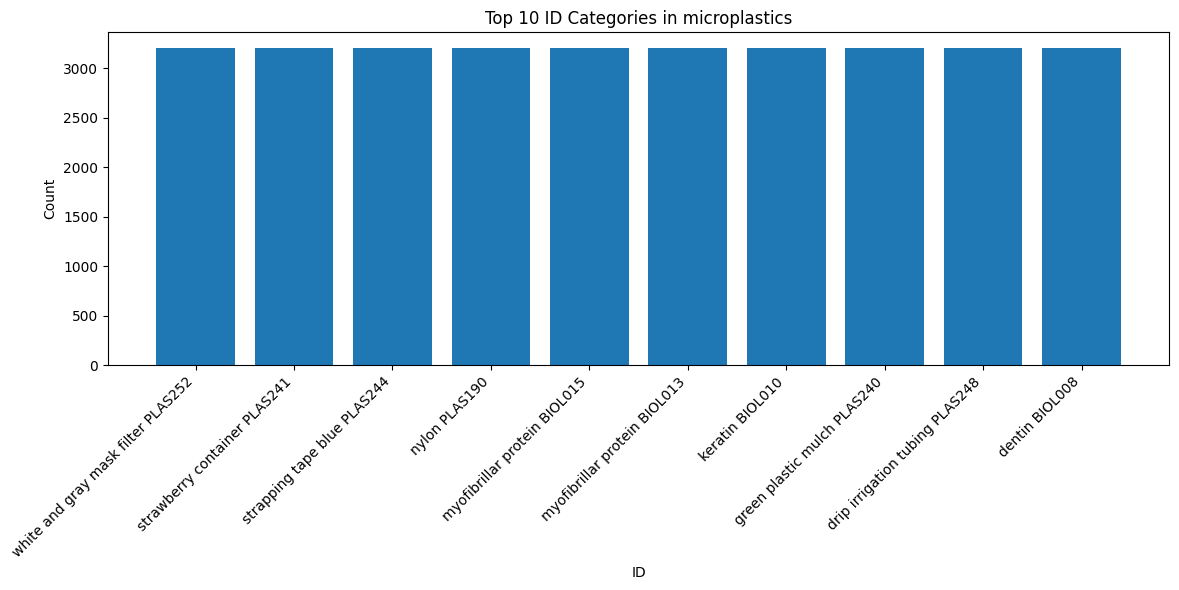

In [20]:
# Let's create some practical examples based on the tables we found

# Example 1: Find specific records in the database
def find_records(table_name, search_column, search_term):
    query = f"SELECT * FROM {table_name} WHERE {search_column} LIKE '%{search_term}%' LIMIT 10"
    result = pd.read_sql_query(query, conn)
    return result

# Example 2: Count records by category
def count_by_category(table_name, category_column):
    query = f"SELECT {category_column}, COUNT(*) as count FROM {table_name} GROUP BY {category_column} ORDER BY count DESC"
    result = pd.read_sql_query(query, conn)
    return result

# Let's run these on the actual tables we have
if tables:
    # Get the first table
    first_table = tables[0][0]
    columns = [col[1] for col in cursor.execute(f"PRAGMA table_info({first_table})").fetchall()]
    
    # Try to find a text column for searching
    text_columns = []
    for col in columns:
        try:
            # Check if this column appears to be text
            query = f"SELECT TYPEOF({col}) FROM {first_table} LIMIT 1"
            result = cursor.execute(query).fetchone()
            if result and result[0] == 'text':
                text_columns.append(col)
        except:
            continue
    
    if text_columns:
        search_col = text_columns[0]  # Use the first text column found
        print(f"\nSearching for records in {first_table}")
        print(f"SQL: SELECT * FROM {first_table} WHERE {search_col} LIKE '%a%' LIMIT 10")
        result = find_records(first_table, search_col, 'a')  # Search for any record containing 'a'
        display(result)
        
        # Try grouping if we have enough records
        try:
            print(f"\nCounting records by category in {first_table}")
            print(f"SQL: SELECT {search_col}, COUNT(*) as count FROM {first_table} GROUP BY {search_col} ORDER BY count DESC")
            result = count_by_category(first_table, search_col)
            display(result)
            
            # Create a bar chart for the category counts
            plt.figure(figsize=(12, 6))
            
            # Limit to top 10 categories if there are many
            if len(result) > 10:
                result = result.head(10)
                plt.title(f"Top 10 {search_col} Categories in {first_table}")
            else:
                plt.title(f"{search_col} Categories in {first_table}")
                
            plt.bar(result[search_col], result['count'])
            plt.xlabel(search_col)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Couldn't group by category: {e}")

## 8. Conclusion

In this tutorial, we've learned how to:

1. Connect to an SQLite database
2. Explore the tables and their structure
3. View data in the tables
4. Create visualizations of the data
5. Write basic SQL queries
6. Apply SQL knowledge to our specific microplastics database

You can now use these skills to further explore the database and extract meaningful information from it.

### Additional Resources for Learning SQL

- [SQLite Documentation](https://www.sqlite.org/docs.html)
- [W3Schools SQL Tutorial](https://www.w3schools.com/sql/)
- [SQLite with Python Documentation](https://docs.python.org/3/library/sqlite3.html)
- [Pandas SQL Query Reference](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql_query.html)

In [ ]:
# Close the database connection
conn.close()
print("Database connection closed.")